In [1]:
# Imports
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
from PIL import Image
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from datetime import datetime
import json
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

# Set save directory
SAVE_DIR = '/content/drive/MyDrive/Deep Learning Project/Si Yue Models'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Models will be saved to: {SAVE_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Models will be saved to: /content/drive/MyDrive/Deep Learning Project/Si Yue Models


In [3]:
# Importing Datasets from Kaggle

# kaggle api token can be generated in your profile settings : https://www.kaggle.com/settings
# save kaggle api token in secrets

from google.colab import userdata
!export KAGGLE_API_TOKEN={userdata.get('KAGGLE_API_TOKEN')}

import kagglehub

# Download latest version of datasets
ds2 = kagglehub.dataset_download("jeftaadriel/oia-odir-dataset")

Using Colab cache for faster access to the 'oia-odir-dataset' dataset.


In [4]:
# Convert files to csv format
off_site_file = pd.read_excel(f"{ds2}/Off-site Test Set/Annotation/off-site test annotation (English).xlsx")
off_site_file.to_csv("off_site_test_annotation.csv", index=None, header=True)

on_site_file = pd.read_excel(f"{ds2}/On-site Test Set/Annotation/on-site test annotation (English).xlsx")
on_site_file.to_csv("on_site_test_annotation.csv", index=None, header=True)

training_file = pd.read_excel(f"{ds2}/Training Set/Annotation/training annotation (English).xlsx")
training_file.to_csv("training_annotation.csv", index=None, header=True)

# Base paths for images
base_path_off_site = ds2 + '/Off-site Test Set/Images/'
base_path_on_site = ds2 + '/On-site Test Set/Images/'
base_path_training = ds2 + '/Training Set/Images/'

# Add image paths to a DataFrame
def process_fundus_image_paths(df, base_path, left_col='Left-Fundus', right_col='Right-Fundus'):
    def add_image_path(filename, current_base_path):
        if pd.isna(filename):
            return filename
        return os.path.join(current_base_path, filename)

    df[left_col] = df[left_col].apply(lambda x: add_image_path(x, base_path))
    df[right_col] = df[right_col].apply(lambda x: add_image_path(x, base_path))
    return df

# Apply to each DataFrame
off_site_file = process_fundus_image_paths(off_site_file, base_path_off_site)
on_site_file = process_fundus_image_paths(on_site_file, base_path_on_site)
training_file = process_fundus_image_paths(training_file, base_path_training)

# Combine all DataFrames into one
df_ds2 = pd.concat([off_site_file, on_site_file, training_file], ignore_index=True)

# Remove specified columns
columns_to_remove = ['ID', 'Patient Age', 'Patient Sex', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
df_ds2 = df_ds2.drop(columns=columns_to_remove)

# Convert Keywords into diagnosis for each eye
disease_mapping = {
    'normal': 'NORMAL',
    'diabetic retinopathy': 'DIABETIC_RETINOPATHY',
    'glaucoma': 'GLAUCOMA',
    'cataract': 'CATARACT',
    'macular degeneration': 'AGE_RELATED_MACULAR_DEGENERATION',
    'age-related macular degeneration': 'AGE_RELATED_MACULAR_DEGENERATION',
    'hypertensive retinopathy': 'HYPERTENSION',
    'myopia': 'MYOPIA',
}

df_left = df_ds2[['Left-Fundus', 'Left-Diagnostic Keywords']].copy()
df_right = df_ds2[['Right-Fundus', 'Right-Diagnostic Keywords']].copy()

df_left.columns = ['image_path', 'eye_disease']
df_right.columns = ['image_path', 'eye_disease']

# Get unique disease codes for column names
disease_codes = list(set(disease_mapping.values()))
disease_codes.append('OTHER_DISEASES')

def parse_diagnosis(df):
    # Initialize all disease columns with 0
    for disease in disease_codes:
        df[disease] = 0

    # Parse each row's diagnostic keywords
    for idx, keywords in df['eye_disease'].items():
        if pd.isna(keywords):
            continue

        # Convert to lowercase for matching
        keywords_lower = str(keywords).lower()

        disease_found = False

        # Check for each disease keyword in the mapping
        for keyword, disease_code in disease_mapping.items():
            if keyword in keywords_lower:
                df.at[idx, disease_code] = 1
                disease_found = True

        if not disease_found:
            df.at[idx, 'OTHER_DISEASES'] = 1

    df = df.drop('eye_disease', axis=1)

    return df

# Apply to both dataframes
df_left = parse_diagnosis(df_left)
df_right = parse_diagnosis(df_right)

# Combine to final dataset
df_ds2 = pd.concat([df_left, df_right], ignore_index=True)

print(df_left)
print(df_right)


                                             image_path  CATARACT  \
0     /kaggle/input/oia-odir-dataset/Off-site Test S...         0   
1     /kaggle/input/oia-odir-dataset/Off-site Test S...         0   
2     /kaggle/input/oia-odir-dataset/Off-site Test S...         0   
3     /kaggle/input/oia-odir-dataset/Off-site Test S...         0   
4     /kaggle/input/oia-odir-dataset/Off-site Test S...         0   
...                                                 ...       ...   
4995  /kaggle/input/oia-odir-dataset/Training Set/Im...         0   
4996  /kaggle/input/oia-odir-dataset/Training Set/Im...         0   
4997  /kaggle/input/oia-odir-dataset/Training Set/Im...         0   
4998  /kaggle/input/oia-odir-dataset/Training Set/Im...         0   
4999  /kaggle/input/oia-odir-dataset/Training Set/Im...         0   

      DIABETIC_RETINOPATHY  HYPERTENSION  MYOPIA  \
0                        0             1       0   
1                        0             0       0   
2              

In [5]:
class EyeDiseaseDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = self.dataframe.iloc[:, 1:].values.astype(float)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]  # First column is image_path
        image = Image.open(img_path).convert('RGB')
        labels = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, labels

In [6]:
def crop_black_borders(image):
    # Convert PIL Image to NumPy array
    img_np = np.array(image)

    # Threshold for black pixels
    BLACK_THRESHOLD = 10

    non_black_pixels = np.any(img_np > BLACK_THRESHOLD, axis=2)

    # Find rows and columns that contain non-black pixels
    rows = np.any(non_black_pixels, axis=1)
    cols = np.any(non_black_pixels, axis=0)

    # Get the min/max indices for cropping
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    # Crop the NumPy array
    cropped_img_np = img_np[rmin:rmax+1, cmin:cmax+1]

    # Convert back to PIL Image
    return Image.fromarray(cropped_img_np)

In [7]:
data_transforms = transforms.Compose([
    transforms.Lambda(crop_black_borders),  # Apply custom cropping function
    transforms.Resize((224, 224)),  # Resize images to 224x224 pixels
    transforms.ToTensor(),  # Convert PIL image to PyTorch tensor
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats
])

full_dataset = EyeDiseaseDataset(dataframe=df_ds2, transform=data_transforms)

# Split into train (70%), validation (15%), test (15%)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size]
)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 7000
Validation size: 1500
Test size: 1500


In [8]:
BATCH_SIZE = 32
NUM_WORKERS = 4

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Number of batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Using device: cpu
Number of batches - Train: 219, Val: 47, Test: 47


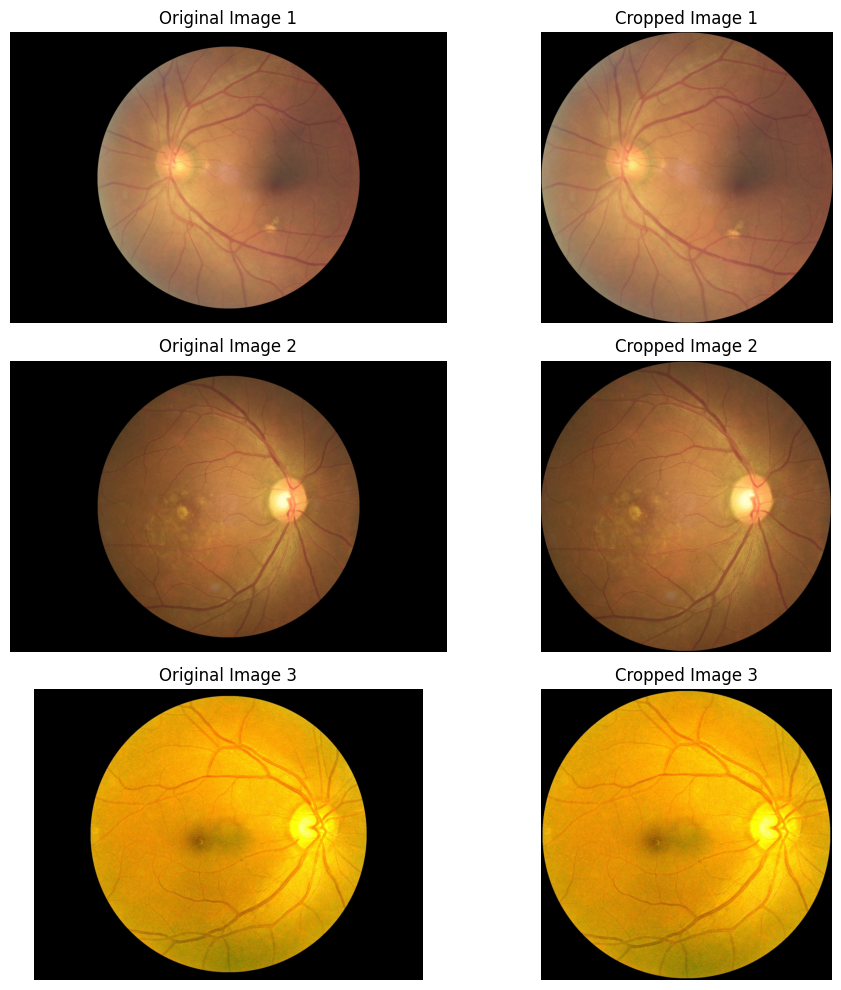

In [9]:
# Select a few sample image paths
sample_image_paths = df_ds2['image_path'].sample(3, random_state=68).tolist()

plt.figure(figsize=(10, 10))

for i, img_path in enumerate(sample_image_paths):
    original_image = Image.open(img_path).convert('RGB')
    cropped_image = crop_black_borders(original_image)

    # Display original image
    plt.subplot(3, 2, 2 * i + 1)
    plt.imshow(original_image)
    plt.title(f"Original Image {i+1}")
    plt.axis('off')

    # Display cropped image
    plt.subplot(3, 2, 2 * i + 2)
    plt.imshow(cropped_image)
    plt.title(f"Cropped Image {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Load a pre-trained model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all parameters efficiently
for param in model.parameters():
    param.requires_grad = False

# Modify final layer
num_features = model.fc.in_features
num_classes = len(disease_codes)

model.fc = nn.Sequential(
    nn.Dropout(p=0.5),  # Add dropout for regularization
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, num_classes)
)

model = model.to(device)
3
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Number of classes: {num_classes}")

Total parameters: 11,309,896
Trainable parameters: 133,384
Number of classes: 8


In [11]:
def get_model_with_lr(lr, weight_decay=1e-4):
    """Create a fresh model with given hyperparameters"""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    model = model.to(device)

    optimizer = optim.Adam(model.fc.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    criterion = nn.BCEWithLogitsLoss()

    return model, optimizer, scheduler, criterion

In [12]:
def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, device, num_epochs=10, patience=3):
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_train_loss = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            predictions = model(inputs)
            loss = criterion(predictions, targets)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation phase
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                predictions = model(inputs)
                loss = criterion(predictions, targets)
                running_val_loss += loss.item() * inputs.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        # Update learning rate
        scheduler.step(epoch_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Early stopping and model saving
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            print(f"  -> New best model! (Val Loss: {best_val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    return best_model_state, best_val_loss, train_losses, val_losses

In [13]:
# Hyperparameter grid
hyperparams = {
    'lr': [0.001, 0.0005, 0.0001],
    'weight_decay': [1e-4, 1e-5]
}

print("Starting hyperparameter tuning...")
best_val_loss = float('inf')
best_config = None
best_weights = None
results = []

for lr in hyperparams['lr']:
    for wd in hyperparams['weight_decay']:
        print(f"\n{'='*50}")
        print(f"Testing: lr={lr}, weight_decay={wd}")
        print('='*50)

        model, optimizer, scheduler, criterion = get_model_with_lr(lr, wd)
        best_state, val_loss, train_losses, val_losses = train_model(
            model, criterion, optimizer, scheduler,
            train_loader, val_loader, device, num_epochs=10
        )

        results.append({
            'lr': lr,
            'weight_decay': wd,
            'best_val_loss': val_loss
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_config = {'lr': lr, 'weight_decay': wd}
            best_weights = best_state

print(f"\n{'='*50}")
print("Hyperparameter Tuning Complete!")
print(f"Best hyperparameters: {best_config}")
print(f"Best validation loss: {best_val_loss:.4f}")
print('='*50)

Starting hyperparameter tuning...

Testing: lr=0.001, weight_decay=0.0001
Epoch 1/10 - Train Loss: 0.2693, Val Loss: 0.2354, LR: 0.001000
  -> New best model! (Val Loss: 0.2354)
Epoch 2/10 - Train Loss: 0.2470, Val Loss: 0.2283, LR: 0.001000
  -> New best model! (Val Loss: 0.2283)
Epoch 3/10 - Train Loss: 0.2411, Val Loss: 0.2280, LR: 0.001000
  -> New best model! (Val Loss: 0.2280)
Epoch 4/10 - Train Loss: 0.2399, Val Loss: 0.2269, LR: 0.001000
  -> New best model! (Val Loss: 0.2269)
Epoch 5/10 - Train Loss: 0.2370, Val Loss: 0.2268, LR: 0.001000
  -> New best model! (Val Loss: 0.2268)
Epoch 6/10 - Train Loss: 0.2362, Val Loss: 0.2258, LR: 0.001000
  -> New best model! (Val Loss: 0.2258)
Epoch 7/10 - Train Loss: 0.2361, Val Loss: 0.2249, LR: 0.001000
  -> New best model! (Val Loss: 0.2249)
Epoch 8/10 - Train Loss: 0.2343, Val Loss: 0.2247, LR: 0.001000
  -> New best model! (Val Loss: 0.2247)
Epoch 9/10 - Train Loss: 0.2349, Val Loss: 0.2260, LR: 0.001000
Epoch 10/10 - Train Loss: 0.23

In [14]:
print("\nTraining final model with best hyperparameters...")
final_model, final_optimizer, final_scheduler, final_criterion = get_model_with_lr(
    best_config['lr'], best_config['weight_decay']
)

final_weights, final_val_loss, train_losses, val_losses = train_model(
    final_model, final_criterion, final_optimizer, final_scheduler,
    train_loader, val_loader, device, num_epochs=10, patience=5
)

# Load best weights
final_model.load_state_dict(final_weights)
print(f"\nFinal model trained! Best validation loss: {final_val_loss:.4f}")


Training final model with best hyperparameters...
Epoch 1/10 - Train Loss: 0.2788, Val Loss: 0.2380, LR: 0.000500
  -> New best model! (Val Loss: 0.2380)
Epoch 2/10 - Train Loss: 0.2483, Val Loss: 0.2302, LR: 0.000500
  -> New best model! (Val Loss: 0.2302)
Epoch 3/10 - Train Loss: 0.2438, Val Loss: 0.2319, LR: 0.000500
Epoch 4/10 - Train Loss: 0.2412, Val Loss: 0.2270, LR: 0.000500
  -> New best model! (Val Loss: 0.2270)
Epoch 5/10 - Train Loss: 0.2384, Val Loss: 0.2280, LR: 0.000500
Epoch 6/10 - Train Loss: 0.2369, Val Loss: 0.2252, LR: 0.000500
  -> New best model! (Val Loss: 0.2252)
Epoch 7/10 - Train Loss: 0.2347, Val Loss: 0.2265, LR: 0.000500
Epoch 8/10 - Train Loss: 0.2342, Val Loss: 0.2284, LR: 0.000500
Epoch 9/10 - Train Loss: 0.2338, Val Loss: 0.2250, LR: 0.000500
  -> New best model! (Val Loss: 0.2250)
Epoch 10/10 - Train Loss: 0.2342, Val Loss: 0.2279, LR: 0.000500

Final model trained! Best validation loss: 0.2250


In [15]:
# Evaluate on test set
final_model.eval()
test_loss = 0.0
all_predictions = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        predictions = final_model(inputs)
        loss = final_criterion(predictions, targets)
        test_loss += loss.item() * inputs.size(0)

        # Apply sigmoid to get probabilities
        probabilities = torch.sigmoid(predictions)
        all_predictions.extend(probabilities.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

test_loss = test_loss / len(test_loader.dataset)
print(f"\nFinal Test Loss: {test_loss:.4f}")

# Calculate metrics
all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)
binary_preds = (all_predictions > 0.5).astype(np.float32)

# Per-class metrics
class_accuracies = (binary_preds == all_targets).mean(axis=0)
print(f"\nMean class accuracy: {class_accuracies.mean():.4f}")
print("\nPer-class accuracy:")
for i, disease in enumerate(disease_codes):
    print(f"  {disease:30s}: {class_accuracies[i]:.4f}")


Final Test Loss: 0.2217

Mean class accuracy: 0.8972

Per-class accuracy:
  CATARACT                      : 0.9820
  DIABETIC_RETINOPATHY          : 0.9873
  HYPERTENSION                  : 0.9767
  MYOPIA                        : 0.9793
  AGE_RELATED_MACULAR_DEGENERATION: 0.9580
  NORMAL                        : 0.6707
  GLAUCOMA                      : 0.9513
  OTHER_DISEASES                : 0.6727


In [16]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs(SAVE_DIR, exist_ok=True)

# Complete checkpoint with all metadata
checkpoint = {
    'model_state_dict': final_weights,
    'model_architecture': 'resnet18',
    'num_classes': num_classes,
    'disease_codes': disease_codes,
    'best_hyperparameters': best_config,
    'batch_size': BATCH_SIZE,
    'best_val_loss': final_val_loss,
    'test_loss': test_loss,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'class_accuracies': class_accuracies.tolist(),
    'timestamp': timestamp,
    'device': str(device),
    'input_size': (3, 224, 224),
    'normalization_stats': {'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]}
}

checkpoint_path = f'{SAVE_DIR}/eye_disease_model_{timestamp}.pth'
torch.save(checkpoint, checkpoint_path)
print(f"Full checkpoint saved to: {checkpoint_path}")

# Weights only
weights_only_path = f'{SAVE_DIR}/model_weights_{timestamp}.pth'
torch.save(final_weights, weights_only_path)
print(f"Weights-only model saved to: {weights_only_path}")

# TorchScript for production
scripted_model = torch.jit.script(final_model)
scripted_path = f'{SAVE_DIR}/model_scripted_{timestamp}.pt'
scripted_model.save(scripted_path)
print(f"TorchScript model saved to: {scripted_path}")

# Save predictions for ensemble
predictions_path = f'{SAVE_DIR}/test_predictions_{timestamp}.npy'
np.save(predictions_path, all_predictions)
print(f"Test predictions saved to: {predictions_path}")

# Save targets for reference
targets_path = f'{SAVE_DIR}/test_targets_{timestamp}.npy'
np.save(targets_path, all_targets)
print(f"Test targets saved to: {targets_path}")

# Save hyperparameter tuning results
results_df = pd.DataFrame(results)
results_df.to_csv(f'{SAVE_DIR}/hyperparameter_tuning_{timestamp}.csv', index=False)
print(f"Hyperparameter results saved to: {SAVE_DIR}/hyperparameter_tuning_{timestamp}.csv")

# Save model configuration for ensemble
config_path = f'{SAVE_DIR}/model_config_{timestamp}.json'
config = {
    'model_name': 'ResNet18_EyeDisease',
    'architecture': 'resnet18',
    'num_classes': num_classes,
    'disease_codes': disease_codes,
    'hyperparameters': best_config,
    'performance': {
        'best_val_loss': final_val_loss,
        'test_loss': test_loss,
        'mean_accuracy': float(class_accuracies.mean()),
        'per_class_accuracy': {disease: float(acc) for disease, acc in zip(disease_codes, class_accuracies)}
    },
    'training_date': timestamp,
    'input_size': [3, 224, 224],
    'normalization': {'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]}
}

with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"Model config saved to: {config_path}")

Full checkpoint saved to: /content/drive/MyDrive/Deep Learning Project/Si Yue Models/eye_disease_model_20260405_135947.pth
Weights-only model saved to: /content/drive/MyDrive/Deep Learning Project/Si Yue Models/model_weights_20260405_135947.pth
TorchScript model saved to: /content/drive/MyDrive/Deep Learning Project/Si Yue Models/model_scripted_20260405_135947.pt
Test predictions saved to: /content/drive/MyDrive/Deep Learning Project/Si Yue Models/test_predictions_20260405_135947.npy
Test targets saved to: /content/drive/MyDrive/Deep Learning Project/Si Yue Models/test_targets_20260405_135947.npy
Hyperparameter results saved to: /content/drive/MyDrive/Deep Learning Project/Si Yue Models/hyperparameter_tuning_20260405_135947.csv
Model config saved to: /content/drive/MyDrive/Deep Learning Project/Si Yue Models/model_config_20260405_135947.json


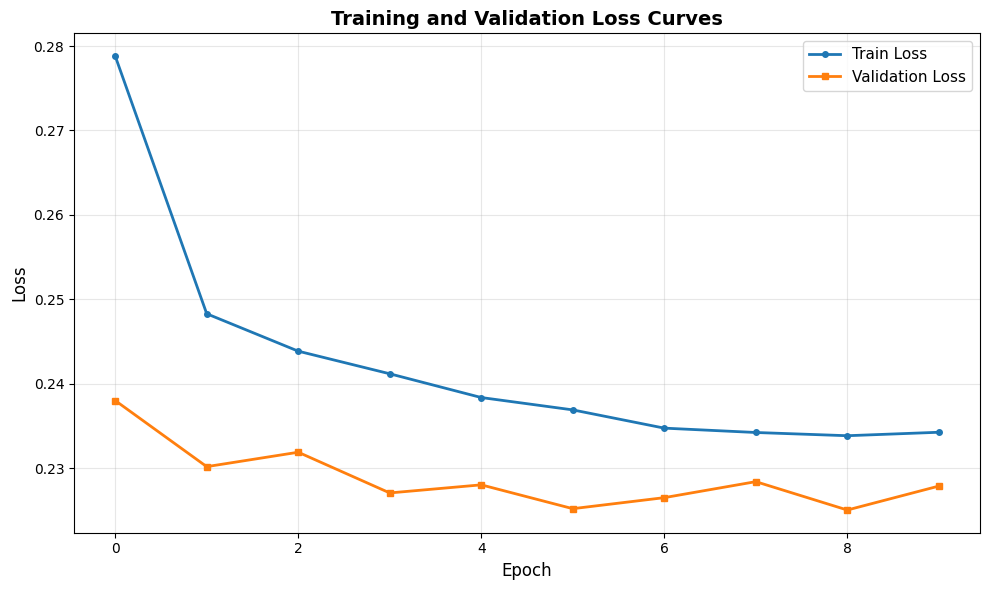

Loss curves saved to: /content/drive/MyDrive/Deep Learning Project/Si Yue Models/loss_curves_20260405_135947.png


In [23]:
# Plot 1: Training and Validation Loss Curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', linewidth=2, marker='o', markersize=4)
plt.plot(val_losses, label='Validation Loss', linewidth=2, marker='s', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/loss_curves_{timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Loss curves saved to: {SAVE_DIR}/loss_curves_{timestamp}.png")

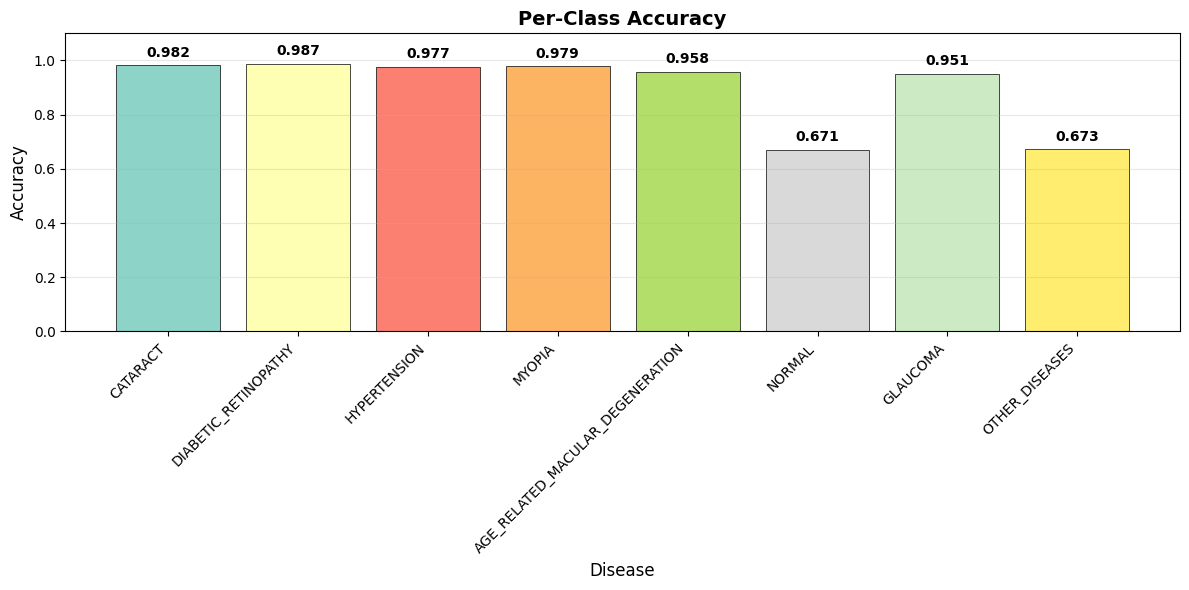

Per-class accuracy saved to: /content/drive/MyDrive/Deep Learning Project/Si Yue Models/per_class_accuracy_20260405_135947.png


In [24]:
# Plot 2: Per-Class Accuracy
plt.figure(figsize=(12, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(disease_codes)))
bars = plt.bar(disease_codes, class_accuracies, color=colors, edgecolor='black', linewidth=0.5)
plt.xlabel('Disease', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, class_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/per_class_accuracy_{timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Per-class accuracy saved to: {SAVE_DIR}/per_class_accuracy_{timestamp}.png")

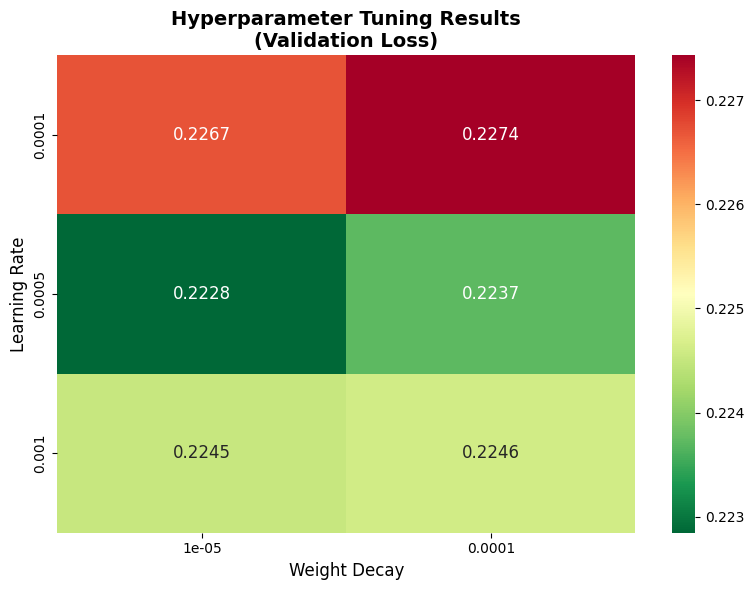

Hyperparameter tuning plot saved to: /content/drive/MyDrive/Deep Learning Project/Si Yue Models/hyperparameter_tuning_20260405_135947.png


In [25]:
# Plot 3: Hyperparameter Tuning Results
plt.figure(figsize=(8, 6))
results_df_pivot = results_df.pivot(index='lr', columns='weight_decay', values='best_val_loss')
sns.heatmap(results_df_pivot, annot=True, fmt='.4f', cmap='RdYlGn_r',
            xticklabels=results_df_pivot.columns, yticklabels=results_df_pivot.index,
            annot_kws={'size': 12})
plt.title('Hyperparameter Tuning Results\n(Validation Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Weight Decay', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/hyperparameter_tuning_{timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Hyperparameter tuning plot saved to: {SAVE_DIR}/hyperparameter_tuning_{timestamp}.png")

In [18]:
files.download(checkpoint_path)
files.download(weights_only_path)
files.download(scripted_path)
files.download(predictions_path)
files.download(targets_path)
files.download(f'{SAVE_DIR}/hyperparameter_tuning_{timestamp}.csv')
files.download(config_path)
files.download(f'{SAVE_DIR}/training_results_{timestamp}.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

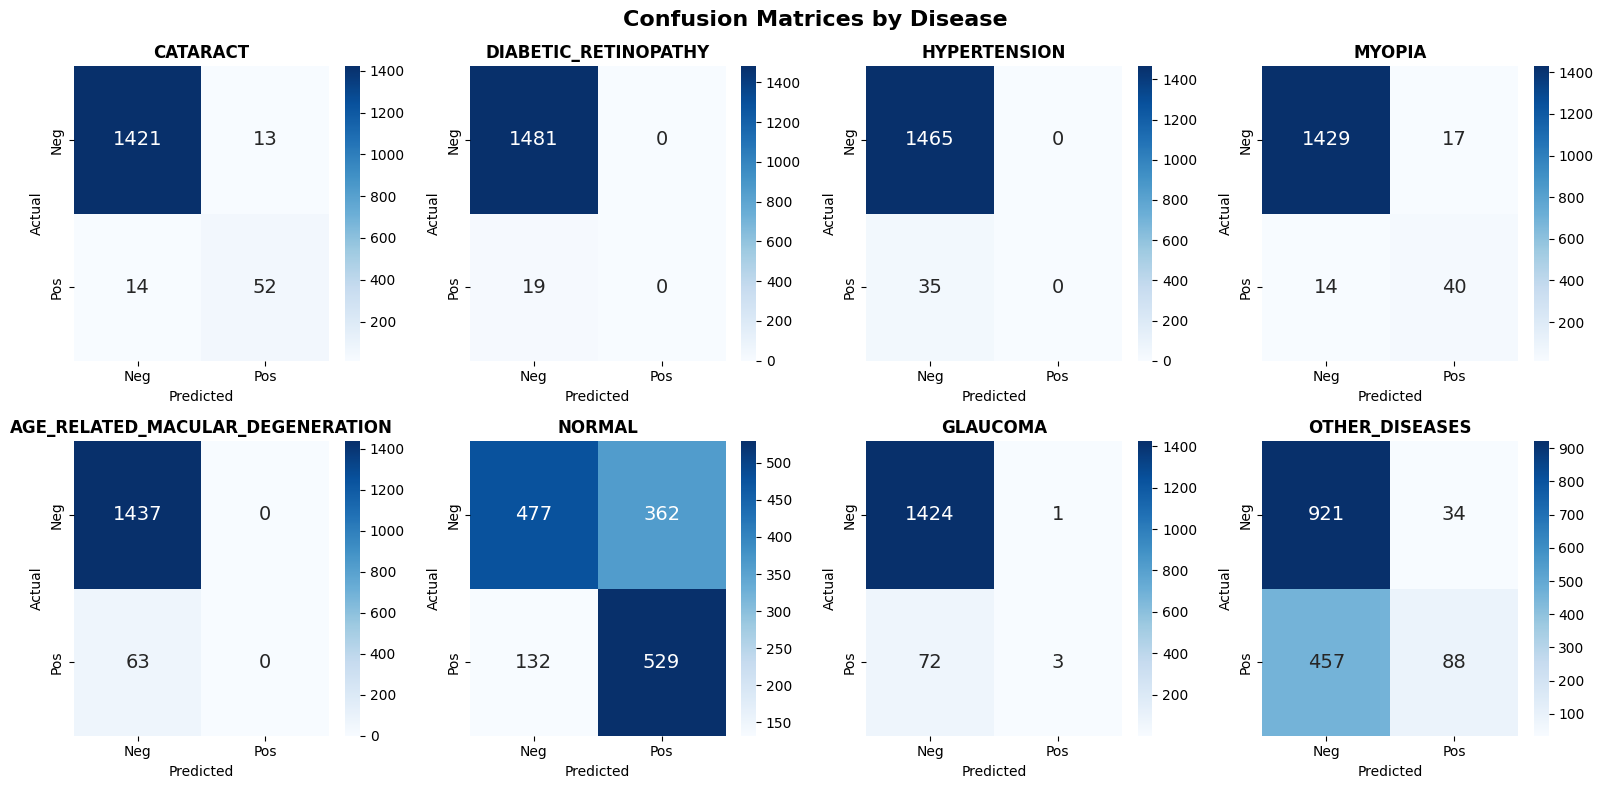

Confusion matrices saved to: /content/drive/MyDrive/Deep Learning Project/Si Yue Models/confusion_matrices_20260405_135947.png


In [37]:
# Plot 5: Confusion matrices for each disease
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, disease in enumerate(disease_codes):
    cm = confusion_matrix(all_targets[:, i], binary_preds[:, i])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
                annot_kws={'size': 14})
    axes[i].set_title(f'{disease}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=10)
    axes[i].set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices by Disease', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrices_{timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Confusion matrices saved to: {SAVE_DIR}/confusion_matrices_{timestamp}.png")

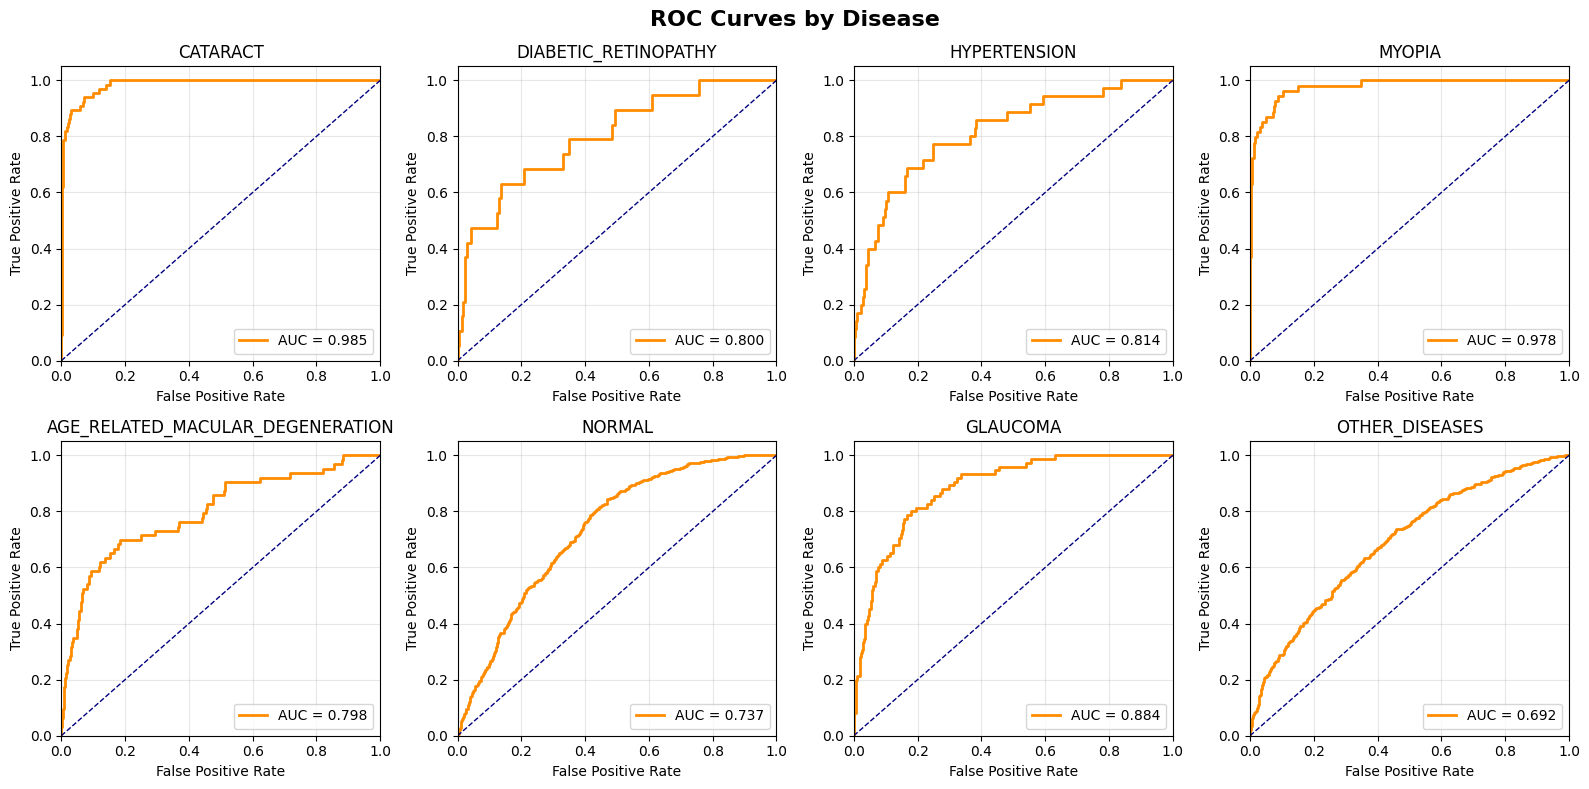

ROC curves saved to: /content/drive/MyDrive/Deep Learning Project/Si Yue Models/roc_curves_20260405_135947.png


In [36]:
# Plot 6: ROC Curves
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, disease in enumerate(disease_codes):
    fpr, tpr, thresholds = roc_curve(all_targets[:, i], all_predictions[:, i])
    roc_auc = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'{disease}')
    axes[i].legend(loc="lower right")
    axes[i].grid(True, alpha=0.3)

plt.suptitle('ROC Curves by Disease', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/roc_curves_{timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC curves saved to: {SAVE_DIR}/roc_curves_{timestamp}.png")

In [45]:
from sklearn.metrics import classification_report

# Standard classification report
print(classification_report(
    all_targets,
    binary_preds,
    target_names=disease_codes,
    digits=4,
    zero_division=0
))

                                  precision    recall  f1-score   support

                        CATARACT     0.8000    0.7879    0.7939        66
            DIABETIC_RETINOPATHY     0.0000    0.0000    0.0000        19
                    HYPERTENSION     0.0000    0.0000    0.0000        35
                          MYOPIA     0.7018    0.7407    0.7207        54
AGE_RELATED_MACULAR_DEGENERATION     0.0000    0.0000    0.0000        63
                          NORMAL     0.5937    0.8003    0.6817       661
                        GLAUCOMA     0.7500    0.0400    0.0759        75
                  OTHER_DISEASES     0.7213    0.1615    0.2639       545

                       micro avg     0.6251    0.4690    0.5359      1518
                       macro avg     0.4458    0.3163    0.3170      1518
                    weighted avg     0.6143    0.4690    0.4555      1518
                     samples avg     0.4737    0.4747    0.4740      1518

